In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 1. SETUP & STRICT GPU CONFIGURATION
# =========================================================
if not torch.cuda.is_available():
    raise SystemError("CUDA is not available! Please check your GPU drivers and PyTorch installation.")

device = torch.device("cuda")
print("="*65)
print(f"[INFO] Using Device  : {device}")
print(f"[INFO] GPU Name      : {torch.cuda.get_device_name(0)}")
print("="*65 + "\n")

# =========================================================
# 2. REAL HDFS DATASET LOADER
# =========================================================
DATA_PATH = r"Dataset\HDFS_v1\preprocessed\HDFS.npz"

def load_real_hdfs(path, max_len=60):
    print(f"[INFO] Loading real dataset from: {path} ...")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at {path}. Please update DATA_PATH.")
    
    data = np.load(path, allow_pickle=True)
    keys = list(data.keys())
    x_key = next((k for k in keys if k.lower() in ("x", "x_data", "data", "features")), keys[0])
    y_key = next((k for k in keys if k.lower() in ("y", "y_data", "label", "labels")),  keys[1])
    
    X_raw = data[x_key]
    y = data[y_key]
    
    unique_events = set()
    for seq in X_raw:
        for event in seq:
            unique_events.add(str(event).strip())
            
    event2id = {event: idx + 1 for idx, event in enumerate(sorted(unique_events))}
    print(f"[INFO] Found {len(event2id)} unique string events. Converting to integers...")
    
    X_encoded = []
    for seq in X_raw:
        X_encoded.append([event2id[str(event).strip()] for event in seq])

    actual_max = max(len(seq) for seq in X_encoded)
    pad_len = min(actual_max, max_len)
    print(f"[INFO] Padding sequences to length {pad_len}...")
    
    padded_X = np.zeros((len(X_encoded), pad_len), dtype=np.int64)
    for i, seq in enumerate(X_encoded):
        trunc = seq[-pad_len:] if len(seq) > pad_len else seq
        padded_X[i, :len(trunc)] = trunc
        
    X = padded_X
        
    if y.dtype == object or isinstance(y[0], (list, np.ndarray)):
        y = np.array([val[0] if isinstance(val, (list, np.ndarray)) else val for val in y])

    if y.dtype.kind in ("U", "S", "O"):
        label_map = {"Normal": 0, "Anomaly": 1}
        y = np.array([label_map.get(str(v), int(v)) if not str(v).isdigit() else int(v) for v in y])
    
    print(f"[INFO] Dataset loaded successfully! X shape: {X.shape}, y shape: {y.shape}")
    return X.astype(np.int64), y.astype(np.int64)

class HDFSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Load Data
X_data, y_data = load_real_hdfs(DATA_PATH)

# Global Configs
VOCAB_SIZE = int(np.max(X_data)) + 2 
EMB_DIM = 64
HIDDEN_SIZE = 128

# Stratified split for fixed Evaluation Set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_data, y_data, test_size=0.3, stratify=y_data, random_state=42
)

test_loader = DataLoader(HDFSDataset(X_test, y_test), batch_size=256, shuffle=False, pin_memory=True)

# =========================================================
# 3. DEEP LEARNING ARCHITECTURES
# =========================================================
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, 2)
        
    def extract_features(self, x):
        e = self.emb(x)
        _, (hn, _) = self.lstm(e)
        return hn[-1]
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.gru = nn.GRU(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, 2)
        
    def extract_features(self, x):
        e = self.emb(x)
        _, hn = self.gru(e)
        return hn[-1]
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.pos_enc = PositionalEncoding(EMB_DIM)
        enc_layer = nn.TransformerEncoderLayer(d_model=EMB_DIM, nhead=4, dim_feedforward=256, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc = nn.Linear(EMB_DIM, 2)
        
    def extract_features(self, x):
        pad_mask = (x == 0)
        e = self.pos_enc(self.emb(x))
        out = self.encoder(e, src_key_padding_mask=pad_mask)
        mask_f = (~pad_mask).unsqueeze(-1).float()
        pooled = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
        return pooled
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

# =========================================================
# 4. TRAINING & EXTRACTION HELPERS
# =========================================================
def pretrain_dl_model(model, loader, epochs=3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    pos_weight = torch.tensor([50.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
    
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits[:, 1], y_batch) 
            loss.backward()
            optimizer.step()

def get_extracted_features(model, loader):
    model = model.to(device)
    model.eval()
    features_list, labels_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            feats = model.extract_features(X_batch) 
            features_list.append(feats.cpu().numpy())
            labels_list.append(y_batch.numpy())
    return np.vstack(features_list), np.concatenate(labels_list)

def get_fresh_models():
    """ Instantiates fresh models for every subset calculation to avoid data leak/fining tuning. """
    dl = {"LSTM": LSTMModel(), "GRU": GRUModel(), "Transformer": TransformerModel()}
    ml = {
        "Decision Tree": DecisionTreeClassifier(criterion="entropy", min_samples_leaf=5, class_weight="balanced", random_state=42),
        "Logistic Regression": LogisticRegression(penalty="l1", solver="saga", C=1.0, class_weight="balanced", max_iter=50, tol=0.01, random_state=42),
        "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True, max_iter=50, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
    }
    return dl, ml

# =========================================================
# 5. RELIABILITY INDEX PIPELINE (10% to 100% Data Scaling)
# =========================================================
data_fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print("\n[START] Beginning Model Reliability Index Test...")

for frac in data_fractions:
    frac_pct = int(frac * 100)
    print("\n" + "="*85)
    print(f"[RELIABILITY TEST] Training with {frac_pct}% of the Training Dataset")
    print("="*85)
    
    # Stratified reduction of training data
    if frac < 1.0:
        X_train_sub, _, y_train_sub, _ = train_test_split(
            X_train_full, y_train_full, train_size=frac, stratify=y_train_full, random_state=42
        )
    else:
        X_train_sub, y_train_sub = X_train_full, y_train_full
        
    print(f"[INFO] Current Subset Size: {len(X_train_sub)} sequences")
    train_loader_sub = DataLoader(HDFSDataset(X_train_sub, y_train_sub), batch_size=256, shuffle=True, pin_memory=True)
    
    # Fresh model weights for this reliability bracket
    dl_models, ml_models = get_fresh_models()
    
    # Setup Table Header for this training fraction
    print(f"\nPERFORMANCE TABLE FOR {frac_pct}% DATASET FRACTION:")
    print("-" * 92)
    print(f"{'DL Base':12s} | {'ML Classifier':20s} | {'Bal_Acc':8s} | {'W_Prec':8s} | {'W_Rec':8s} | {'W_F1':8s}")
    print("-" * 92)
    
    # Matrix execution
    for dl_name, dl_model in dl_models.items():
        pretrain_dl_model(dl_model, train_loader_sub, epochs=3)
        
        # Extract features
        X_train_features, y_train_ml = get_extracted_features(dl_model, train_loader_sub)
        X_test_features, y_test_ml   = get_extracted_features(dl_model, test_loader)
        
        for ml_name, ml_model in ml_models.items():
            ml_model.fit(X_train_features, y_train_ml)
            preds = ml_model.predict(X_test_features)
            
            # Metrics
            acc = balanced_accuracy_score(y_test_ml, preds)
            pre = precision_score(y_test_ml, preds, average='weighted', zero_division=0)
            rec = recall_score(y_test_ml, preds, average='weighted', zero_division=0)
            f1  = f1_score(y_test_ml, preds, average='weighted', zero_division=0)
            
            # Print row inside the table
            print(f"{dl_name:12s} | {ml_name:20s} | {acc:.4f}  | {pre:.4f}  | {rec:.4f}  | {f1:.4f}")
            
    print("-" * 92)

print("\n[INFO] Reliability Scaling Test Complete!")

[INFO] Using Device  : cuda
[INFO] GPU Name      : NVIDIA GeForce RTX 4060 Laptop GPU

[INFO] Loading real dataset from: Dataset\HDFS_v1\preprocessed\HDFS.npz ...
[INFO] Found 29 unique string events. Converting to integers...
[INFO] Padding sequences to length 60...
[INFO] Dataset loaded successfully! X shape: (575061, 60), y shape: (575061,)

[START] Beginning Model Reliability Index Test...

[RELIABILITY TEST] Training with 10% of the Training Dataset
[INFO] Current Subset Size: 40254 sequences

PERFORMANCE TABLE FOR 10% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9850  | 0.9959  | 0.9956  | 0.9957


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LSTM         | Logistic Regression  | 0.7157  | 0.9763  | 0.9792  | 0.9765


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9784  | 0.9981  | 0.9982  | 0.9981
GRU          | Decision Tree        | 0.9953  | 0.9989  | 0.9989  | 0.9989


...

GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9984  | 0.9998  | 0.9998  | 0.9998
Transformer  | Decision Tree        | 0.9984  | 0.9997  | 0.9997  | 0.9997


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Transformer  | Logistic Regression  | 0.9984  | 0.9987  | 0.9986  | 0.9986


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9981  | 0.9997  | 0.9997  | 0.9997
--------------------------------------------------------------------------------------------

[INFO] Reliability Scaling Test Complete!


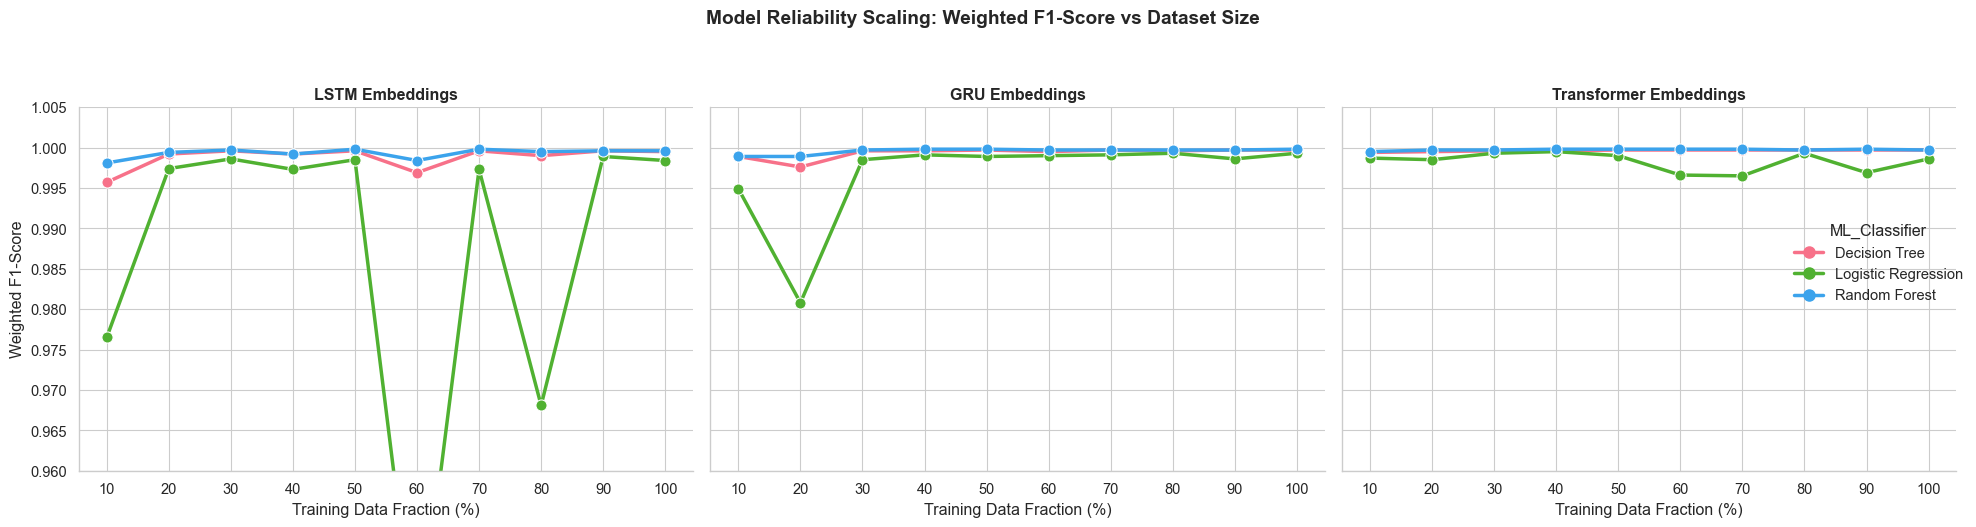

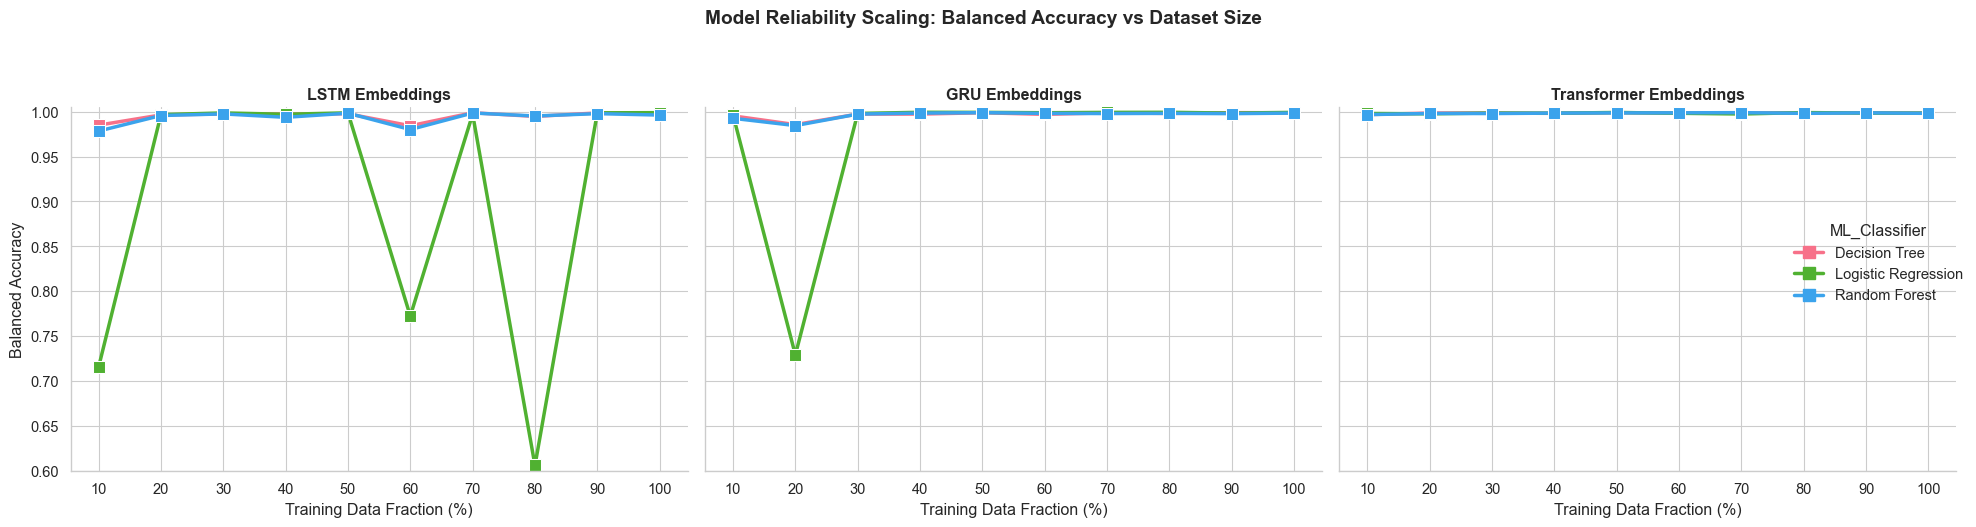

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Paste your raw terminal output here
raw_output = r"""
=================================================================
[INFO] Using Device  : cuda
[INFO] GPU Name      : NVIDIA GeForce RTX 4060 Laptop GPU
=================================================================

[INFO] Loading real dataset from: Dataset\HDFS_v1\preprocessed\HDFS.npz ...
[INFO] Found 29 unique string events. Converting to integers...
[INFO] Padding sequences to length 60...
[INFO] Dataset loaded successfully! X shape: (575061, 60), y shape: (575061,)

[START] Beginning Model Reliability Index Test...

=====================================================================================
[RELIABILITY TEST] Training with 10% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 40254 sequences

PERFORMANCE TABLE FOR 10% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9850  | 0.9959  | 0.9956  | 0.9957
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.7157  | 0.9763  | 0.9792  | 0.9765
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9784  | 0.9981  | 0.9982  | 0.9981
GRU          | Decision Tree        | 0.9953  | 0.9989  | 0.9989  | 0.9989
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9964  | 0.9955  | 0.9947  | 0.9949
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.9921  | 0.9899  | 0.9847  | 0.9862
GRU          | Random Forest        | 0.9926  | 0.9989  | 0.9989  | 0.9989
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(
Transformer  | Decision Tree        | 0.9967  | 0.9994  | 0.9994  | 0.9994
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9980  | 0.9987  | 0.9986  | 0.9987
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.9981  | 0.9987  | 0.9986  | 0.9987
Transformer  | Random Forest        | 0.9967  | 0.9995  | 0.9995  | 0.9995
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 20% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 80508 sequences

PERFORMANCE TABLE FOR 20% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9964  | 0.9992  | 0.9992  | 0.9992
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9967  | 0.9975  | 0.9973  | 0.9974
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9957  | 0.9994  | 0.9994  | 0.9994
GRU          | Decision Tree        | 0.9856  | 0.9976  | 0.9976  | 0.9976
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.7291  | 0.9834  | 0.9837  | 0.9808
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9845  | 0.9989  | 0.9989  | 0.9989
Transformer  | Decision Tree        | 0.9985  | 0.9995  | 0.9995  | 0.9995
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9976  | 0.9986  | 0.9985  | 0.9985
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9980  | 0.9997  | 0.9997  | 0.9997
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 30% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 120762 sequences

PERFORMANCE TABLE FOR 30% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9974  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9986  | 0.9986  | 0.9986  | 0.9986
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5950  | 0.9505  | 0.8049  | 0.8674
LSTM         | Random Forest        | 0.9975  | 0.9997  | 0.9997  | 0.9997
GRU          | Decision Tree        | 0.9973  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9980  | 0.9986  | 0.9985  | 0.9985
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9973  | 0.9997  | 0.9997  | 0.9997
Transformer  | Decision Tree        | 0.9985  | 0.9996  | 0.9996  | 0.9996
Transformer  | Logistic Regression  | 0.9985  | 0.9993  | 0.9993  | 0.9993
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9979  | 0.9997  | 0.9997  | 0.9997
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 40% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 161016 sequences

PERFORMANCE TABLE FOR 40% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9975  | 0.9992  | 0.9992  | 0.9992
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9971  | 0.9975  | 0.9972  | 0.9973
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9937  | 0.9992  | 0.9992  | 0.9992
GRU          | Decision Tree        | 0.9973  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9993  | 0.9992  | 0.9991  | 0.9991
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.9967  | 0.9947  | 0.9936  | 0.9939
GRU          | Random Forest        | 0.9984  | 0.9998  | 0.9998  | 0.9998
Transformer  | Decision Tree        | 0.9981  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9983  | 0.9995  | 0.9995  | 0.9995
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9984  | 0.9998  | 0.9998  | 0.9998
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 50% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 201271 sequences

PERFORMANCE TABLE FOR 50% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9976  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9987  | 0.9986  | 0.9985  | 0.9985
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9983  | 0.9998  | 0.9998  | 0.9998
GRU          | Decision Tree        | 0.9988  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9992  | 0.9989  | 0.9989  | 0.9989
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9989  | 0.9998  | 0.9998  | 0.9998
Transformer  | Decision Tree        | 0.9989  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9991  | 0.9991  | 0.9990  | 0.9990
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9986  | 0.9998  | 0.9998  | 0.9998
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 60% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 241525 sequences

PERFORMANCE TABLE FOR 60% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9843  | 0.9969  | 0.9968  | 0.9969
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.7724  | 0.9647  | 0.9169  | 0.9367
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9801  | 0.9984  | 0.9984  | 0.9984
GRU          | Decision Tree        | 0.9970  | 0.9995  | 0.9995  | 0.9995
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9988  | 0.9991  | 0.9990  | 0.9990
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9981  | 0.9997  | 0.9997  | 0.9997
Transformer  | Decision Tree        | 0.9984  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9982  | 0.9969  | 0.9965  | 0.9966
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9987  | 0.9998  | 0.9998  | 0.9998
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 70% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 281779 sequences

PERFORMANCE TABLE FOR 70% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9988  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9972  | 0.9975  | 0.9973  | 0.9973
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9985  | 0.9998  | 0.9998  | 0.9998
GRU          | Decision Tree        | 0.9987  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9992  | 0.9991  | 0.9991  | 0.9991
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9979  | 0.9997  | 0.9997  | 0.9997
Transformer  | Decision Tree        | 0.9985  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9974  | 0.9968  | 0.9965  | 0.9965
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9989  | 0.9998  | 0.9998  | 0.9998
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 80% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 322033 sequences

PERFORMANCE TABLE FOR 80% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9947  | 0.9990  | 0.9990  | 0.9990
LSTM         | Logistic Regression  | 0.6060  | 0.9704  | 0.9750  | 0.9681
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9952  | 0.9995  | 0.9995  | 0.9995
GRU          | Decision Tree        | 0.9980  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9993  | 0.9993  | 0.9993  | 0.9993
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9981  | 0.9997  | 0.9997  | 0.9997
Transformer  | Decision Tree        | 0.9988  | 0.9997  | 0.9997  | 0.9997
Transformer  | Logistic Regression  | 0.9990  | 0.9993  | 0.9993  | 0.9993
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9981  | 0.9997  | 0.9997  | 0.9997
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 90% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 362287 sequences

PERFORMANCE TABLE FOR 90% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9986  | 0.9996  | 0.9996  | 0.9996
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9987  | 0.9989  | 0.9989  | 0.9989
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9978  | 0.9996  | 0.9996  | 0.9996
GRU          | Decision Tree        | 0.9989  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9984  | 0.9987  | 0.9986  | 0.9986
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9978  | 0.9997  | 0.9997  | 0.9997
Transformer  | Decision Tree        | 0.9987  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9984  | 0.9971  | 0.9968  | 0.9969
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9987  | 0.9998  | 0.9998  | 0.9998
--------------------------------------------------------------------------------------------

=====================================================================================
[RELIABILITY TEST] Training with 100% of the Training Dataset
=====================================================================================
[INFO] Current Subset Size: 402542 sequences

PERFORMANCE TABLE FOR 100% DATASET FRACTION:
--------------------------------------------------------------------------------------------
DL Base      | ML Classifier        | Bal_Acc  | W_Prec   | W_Rec    | W_F1    
--------------------------------------------------------------------------------------------
LSTM         | Decision Tree        | 0.9980  | 0.9995  | 0.9995  | 0.9995
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
LSTM         | Logistic Regression  | 0.9989  | 0.9985  | 0.9984  | 0.9984
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
LSTM         | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
LSTM         | Random Forest        | 0.9962  | 0.9996  | 0.9996  | 0.9996
GRU          | Decision Tree        | 0.9988  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GRU          | Logistic Regression  | 0.9992  | 0.9993  | 0.9993  | 0.9993
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
GRU          | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
GRU          | Random Forest        | 0.9984  | 0.9998  | 0.9998  | 0.9998
Transformer  | Decision Tree        | 0.9984  | 0.9997  | 0.9997  | 0.9997
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Transformer  | Logistic Regression  | 0.9984  | 0.9987  | 0.9986  | 0.9986
c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Transformer  | SVM                  | 0.5000  | 0.0009  | 0.0293  | 0.0017
Transformer  | Random Forest        | 0.9981  | 0.9997  | 0.9997  | 0.9997
--------------------------------------------------------------------------------------------

[INFO] Reliability Scaling Test Complete!
"""

def parse_output_to_dataframe(text_output):
    data = []
    current_fraction = None
    
    for line in text_output.split('\n'):
        # Detect the dataset fraction block
        frac_match = re.search(r'PERFORMANCE TABLE FOR (\d+)% DATASET FRACTION', line)
        if frac_match:
            current_fraction = int(frac_match.group(1))
            continue
            
        # Extract the model metrics, ignoring warnings and separator lines
        row_match = re.match(r'^(LSTM|GRU|Transformer)\s+\|\s+([a-zA-Z\s]+?)\s+\|\s+([0-9.]+)\s+\|\s+([0-9.]+)\s+\|\s+([0-9.]+)\s+\|\s+([0-9.]+)', line.strip())
        if row_match and current_fraction is not None:
            data.append({
                'Data_Fraction': current_fraction,
                'DL_Base': row_match.group(1).strip(),
                'ML_Classifier': row_match.group(2).strip(),
                'Bal_Acc': float(row_match.group(3)),
                'W_Prec': float(row_match.group(4)),
                'W_Rec': float(row_match.group(5)),
                'W_F1': float(row_match.group(6))
            })
            
    return pd.DataFrame(data)

# 2. Parse the data
df = parse_output_to_dataframe(raw_output)

# Optional: Filter out SVM since it failed to converge and its low scores (0.0017) 
# will skew the Y-axis, making it hard to see the differences between the top performers.
df_filtered = df[df['ML_Classifier'] != 'SVM']

# 3. Setup Visualization Style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("husl", len(df_filtered['ML_Classifier'].unique()))

# 4. Generate the Visualization (Weighted F1 Score)
g = sns.relplot(
    data=df_filtered,
    x='Data_Fraction', 
    y='W_F1',
    hue='ML_Classifier', 
    col='DL_Base',
    kind='line', 
    marker='o',
    linewidth=2.5,
    markersize=8,
    palette=palette,
    height=5, 
    aspect=1.2
)

# 5. Formatting the plots
g.fig.suptitle('Model Reliability Scaling: Weighted F1-Score vs Dataset Size', y=1.05, fontweight='bold')
g.set_axis_labels('Training Data Fraction (%)', 'Weighted F1-Score')
g.set_titles(col_template="{col_name} Embeddings", fontweight='bold')

# Adjust axes to better highlight the top-tier performance (since most are >0.98)
for ax in g.axes.flat:
    ax.set_ylim(0.96, 1.005)
    ax.set_xticks(range(10, 110, 10))

plt.tight_layout()
plt.show()

# 6. Generate a second visualization for Balanced Accuracy
g2 = sns.relplot(
    data=df_filtered,
    x='Data_Fraction', 
    y='Bal_Acc',
    hue='ML_Classifier', 
    col='DL_Base',
    kind='line', 
    marker='s', # Square markers
    linewidth=2.5,
    markersize=8,
    palette=palette,
    height=5, 
    aspect=1.2
)

g2.fig.suptitle('Model Reliability Scaling: Balanced Accuracy vs Dataset Size', y=1.05, fontweight='bold')
g2.set_axis_labels('Training Data Fraction (%)', 'Balanced Accuracy')
g2.set_titles(col_template="{col_name} Embeddings", fontweight='bold')

for ax in g2.axes.flat:
    ax.set_ylim(0.60, 1.005) # Lower bound adjusted to catch the Logistic Regression dips
    ax.set_xticks(range(10, 110, 10))

plt.tight_layout()
plt.show()